# Fitting and comparing TabICL for claims frequency

This notebook follows the data preparation, train/test split, model comparison, and calibration workflow, using the local `freMTPL2freq.csv` file.

The comparison includes an exposure-based null model, a Poisson GLM, four tree ensembles (random forest, extra trees, CatBoost, and XGBoost), and TabICL. CatBoost and XGBoost are each fitted on the full training partition and again on the same claim-count-stratified contexts used by TabICL at each `TABICL_CONTEXT_SIZES` value. Contexts are nested prefixes of one seeded row order stratified by `ClaimNb` bins (0, 1, and 2+), and every model predicts on the same full holdout.

In [1]:
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from IPython.display import display
from skrub import TableVectorizer
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import PoissonRegressor
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from tabicl import TabICLRegressor
from xgboost import XGBRegressor

SEED = 13579

c:\Users\alygu\anaconda3\envs\env_tabicl\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load the motor-claims data

The feature columns match the French motor third-party liability example in the CANN notebook. `ClaimNb` is the observed claim count and `Exposure` is the policy time at risk. All valid rows are loaded. The classical frequency models fit `ClaimNb / Exposure` with `Exposure` as `sample_weight`; TabICL uses a context sample stratified by `ClaimNb` bins because its documented `fit(X, y)` API has no `sample_weight` argument.

In [2]:
feature_columns = [
    'Area',
    'VehBrand',
    'VehGas',
    'Region',
    'BonusMalus',
    'VehPower',
    'VehAge',
    'DrivAge',
    'Density',
]
required_columns = feature_columns + ['ClaimNb', 'Exposure']

candidate_paths = [
    Path('freMTPL2freq.csv'),
    Path('modelling') / 'freMTPL2freq.csv',
]
data_path = next((path for path in candidate_paths if path.is_file()), None)
if data_path is None:
    raise FileNotFoundError(
        'Expected freMTPL2freq.csv beside this notebook or under ./modelling.'
    )

data = pd.read_csv(data_path)
missing_columns = sorted(set(required_columns).difference(data.columns))
if missing_columns:
    raise ValueError(f'Missing required columns in {data_path}: {missing_columns}')
data = data[required_columns].copy()
if data.isna().any().any():
    columns_with_missing = data.columns[data.isna().any()].tolist()
    raise ValueError(f'Missing values in required columns: {columns_with_missing}')
if not data['Exposure'].gt(0).all():
    raise ValueError('Exposure must be strictly positive for frequency modelling.')
if not data['ClaimNb'].ge(0).all():
    raise ValueError('ClaimNb must be non-negative.')

rows_loaded = len(data)
data = data.reset_index(drop=True)

print(f'Loaded {rows_loaded:,} rows from {data_path}.')
print(f'Using the full dataset of {len(data):,} policies for modelling.')
print(f'Claims in dataset: {int(data.ClaimNb.sum()):,}')
print(
    f'Observed frequency: '
    f'{data.ClaimNb.sum() / data.Exposure.sum():.3f} claims per exposure unit'
)
display(data.head())

Loaded 678,013 rows from freMTPL2freq.csv.
Using the full dataset of 678,013 policies for modelling.
Claims in dataset: 36,102
Observed frequency: 0.101 claims per exposure unit


,Area,VehBrand,VehGas,Region,BonusMalus,VehPower,VehAge,DrivAge,Density,ClaimNb,Exposure
0,D,B12,Regular,R82,50,5,0,55,1217,1,0.10
1,D,B12,Regular,R82,50,5,0,55,1217,1,0.77
2,B,B12,Diesel,R22,50,6,2,52,54,1,0.75
3,B,B12,Diesel,R72,50,7,0,46,76,1,0.09
4,B,B12,Diesel,R72,50,7,0,46,76,1,0.84


## Split the data

Keep the holdout set out of fitting. Exposure is retained separately for weighting, the portfolio baseline, and frequency calibration.

In [3]:
X = data[feature_columns]
y_claims = data['ClaimNb']
exposure = data['Exposure']
y_frequency = y_claims / exposure

(
    X_train,
    X_test,
    y_train_frequency,
    y_test_frequency,
    y_train_claims,
    y_test_claims,
    exposure_train,
    exposure_test,
) = train_test_split(
    X,
    y_frequency,
    y_claims,
    exposure,
    test_size=0.25,
    random_state=SEED,
)
print(f'Train rows: {len(X_train):,}; test rows: {len(X_test):,}')

Train rows: 508,509; test rows: 169,504


## Define the models

`TabICLRegressor` uses the documented `fit` / `predict` interface, with in-context predictions produced at `predict` time. The Poisson GLM, random forest, extra trees, and XGBoost use `TableVectorizer` for mixed categorical and numeric columns; CatBoost receives the raw categorical columns. Conventional models are fitted on the full training partition with exposure sample weights. CatBoost and XGBoost are also refitted on each context subset, retaining exposure sample weights. TabICL does not accept `sample_weight`; its contexts use one seeded row order stratified by `ClaimNb` bins (0, 1, 2+), without exposure-proportional sampling. Contexts are nested prefixes of that order. Each context predicts the same full test partition. The fit cell checks PyTorch CUDA availability, explicitly selects CUDA when available, and prints TabICL's resolved device. If PyTorch cannot see CUDA, install a CUDA-enabled PyTorch build for this notebook kernel; see the [PyTorch install selector](https://pytorch.org/get-started/locally/). KV caching is enabled for repeated test batches and uses additional memory.

In [4]:
categorical_columns = X_train.select_dtypes(
    include=['object', 'category']
).columns.tolist()

baseline_models = {
    'Poisson GLM': make_pipeline(
        TableVectorizer(), 
        StandardScaler(with_mean=False),
        PoissonRegressor(alpha=0.05,max_iter=2_000, tol=1e-7)
    ),
    'Random forest': make_pipeline(
        TableVectorizer(),
        StandardScaler(with_mean=False),
        RandomForestRegressor(
            criterion='poisson',
            n_estimators=200,
            n_jobs=-1,
            random_state=SEED,
        ),
    ),
    'CatBoost': make_pipeline(
        CatBoostRegressor(
            loss_function='Poisson',
            iterations=500,
            depth=8,
            learning_rate=0.05,
            cat_features=categorical_columns,
            random_seed=SEED,
            thread_count=-1,
            verbose=False,
            allow_writing_files=False,
        ),
    ),
    'XGBoost': make_pipeline(
        TableVectorizer(),
        XGBRegressor(
            objective='count:poisson',
            n_estimators=500,
            learning_rate=0.05,
            max_depth=6,
            subsample=0.8,
            colsample_bytree=0.8,
            tree_method='hist',
            n_jobs=-1,
            random_state=SEED,
            verbosity=0,
        ),
    ),
}

TABICL_CONTEXT_SIZES = (1_000, 5_000, 10_000, 20_000, 30_000)
TABICL_CONTEXT_AND_TEST_BATCH_TARGET = 32_000
TABICL_MIN_TEST_BATCH_SIZE = 2_000

## Fit and predict

The null model predicts the training portfolio's claims per exposure unit. The GLM and other full-data tree models fit claim frequency with exposure weights on all training rows. CatBoost and XGBoost are additionally fitted with exposure weights on each stratified context used by TabICL. Contexts are nested prefixes stratified by `ClaimNb` bins (0, 1, 2+). Predictions use the full test partition; TabICL prediction batches are `max(2,000, 32,000 - context size)` rows.

In [5]:
import torch

def stratified_context_indices(y_claims, context_sizes):
    """Return nested prefixes of a claim-count-stratified row order."""
    claim_counts = np.asarray(y_claims, dtype=int)
    if not context_sizes:
        raise ValueError('At least one context size is required.')
    if min(context_sizes) < 1 or max(context_sizes) >= len(claim_counts):
        raise ValueError('Context sizes must be smaller than the training partition.')

    strata = np.minimum(claim_counts, 2)
    stratum_labels = np.unique(strata)
    rows_by_stratum = [
        np.flatnonzero(strata == label)
        for label in stratum_labels
    ]
    stratum_shares = np.array([len(rows) for rows in rows_by_stratum], dtype=float)
    stratum_shares /= stratum_shares.sum()

    max_context_size = max(context_sizes)
    rng = np.random.default_rng(SEED)
    stratum_order = np.empty(max_context_size, dtype=int)
    allocated = np.zeros(len(stratum_labels), dtype=int)
    for position in range(max_context_size):
        deficits = (position + 1) * stratum_shares - allocated
        stratum_id = int(np.argmax(deficits))
        stratum_order[position] = stratum_id
        allocated[stratum_id] += 1

    rows_by_stratum = [rng.permutation(rows) for rows in rows_by_stratum]
    offsets = np.zeros(len(stratum_labels), dtype=int)
    context_order = np.empty(max_context_size, dtype=int)
    for position, stratum_id in enumerate(stratum_order):
        context_order[position] = rows_by_stratum[stratum_id][offsets[stratum_id]]
        offsets[stratum_id] += 1

    return {size: context_order[:size] for size in context_sizes}


def make_context_model(model_name):
    baseline_model = baseline_models[model_name]
    if model_name == 'CatBoost':
        # CatBoost's cat_features parameter is not compatible with sklearn.clone.
        return make_pipeline(
            CatBoostRegressor(**baseline_model.steps[-1][1].get_params())
        )
    return clone(baseline_model)


def fit_predict_weighted_model(
    model_name,
    model,
    X_fit,
    y_fit,
    sample_weight,
    X_predict,
    exposure_predict,
):
    final_step_name = model.steps[-1][0]
    print(f'Fitting {model_name}...')
    fit_start = perf_counter()
    model.fit(
        X_fit,
        y_fit,
        **{f'{final_step_name}__sample_weight': sample_weight},
    )
    fit_seconds = perf_counter() - fit_start

    predict_start = perf_counter()
    frequency_prediction = np.asarray(
        model.predict(X_predict), dtype=float
    ).reshape(-1)
    if len(frequency_prediction) != len(X_predict):
        raise RuntimeError(f'{model_name} did not predict every test row.')
    predict_seconds = perf_counter() - predict_start
    claim_prediction = (
        np.maximum(frequency_prediction, 1e-8)
        * exposure_predict.to_numpy(dtype=float)
    )
    return claim_prediction, fit_seconds, predict_seconds


def predict_in_batches(model, X, batch_size, model_name):
    predictions = []
    for start in range(0, len(X), batch_size):
        stop = min(start + batch_size, len(X))
        predictions.append(
            np.asarray(model.predict(X.iloc[start:stop]), dtype=float).reshape(-1)
        )
    prediction = np.concatenate(predictions)
    if len(prediction) != len(X):
        raise RuntimeError(f'{model_name} did not predict every test row.')
    return prediction


if torch.cuda.is_available():
    TABICL_DEVICE = 'cuda'
    print(f'CUDA available to PyTorch: {torch.cuda.get_device_name(0)}')
else:
    TABICL_DEVICE = None
    print(
        f'CUDA unavailable to PyTorch (version={torch.__version__}, '
        f'CUDA build={torch.version.cuda}); TabICL will auto-select a device.'
    )

elapsed_fit_seconds = {}
elapsed_predict_seconds = {}

start_time = perf_counter()
training_frequency = y_train_claims.sum() / exposure_train.sum()
elapsed_fit_seconds['Exposure-weighted null'] = perf_counter() - start_time
predict_start = perf_counter()
predicted_claims = {
    'Exposure-weighted null': training_frequency * exposure_test.to_numpy()
}
elapsed_predict_seconds['Exposure-weighted null'] = perf_counter() - predict_start

for model_name, model in baseline_models.items():
    (
        predicted_claims[model_name],
        elapsed_fit_seconds[model_name],
        elapsed_predict_seconds[model_name],
    ) = fit_predict_weighted_model(
        model_name,
        model,
        X_train,
        y_train_frequency,
        exposure_train,
        X_test,
        exposure_test,
    )

context_indices_by_size = stratified_context_indices(
    y_train_claims,
    TABICL_CONTEXT_SIZES,
)

for context_size in TABICL_CONTEXT_SIZES:
    tabicl_test_batch_size = max(
        TABICL_MIN_TEST_BATCH_SIZE,
        TABICL_CONTEXT_AND_TEST_BATCH_TARGET - context_size,
    )
    context_indices = context_indices_by_size[context_size]
    context_X_train = X_train.iloc[context_indices]
    context_y_train_frequency = y_train_frequency.iloc[context_indices]
    context_exposure_train = exposure_train.iloc[context_indices]

    for baseline_model_name in ('CatBoost', 'XGBoost'):
        context_model_name = f'{baseline_model_name} (context={context_size:,})'
        context_model = make_context_model(baseline_model_name)
        (
            predicted_claims[context_model_name],
            elapsed_fit_seconds[context_model_name],
            elapsed_predict_seconds[context_model_name],
        ) = fit_predict_weighted_model(
            context_model_name,
            context_model,
            context_X_train,
            context_y_train_frequency,
            context_exposure_train,
            X_test,
            exposure_test,
        )

    model_name = f'TabICL (context={context_size:,})'
    tabicl_model = make_pipeline(
        TabICLRegressor(device=TABICL_DEVICE, kv_cache=True),
    )
    print(f'Fitting {model_name}...')
    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    start_time = perf_counter()
    tabicl_model.fit(
        context_X_train,
        y_train_frequency.iloc[context_indices],
    )
    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    elapsed_fit_seconds[model_name] = perf_counter() - start_time
    tabicl_estimator = tabicl_model.steps[-1][1]
    print(f'{model_name} resolved device: {tabicl_estimator.device_}')

    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    predict_start = perf_counter()
    model_frequency_prediction = predict_in_batches(
        tabicl_model,
        X_test,
        tabicl_test_batch_size,
        model_name,
    )
    if TABICL_DEVICE == 'cuda':
        torch.cuda.synchronize()
    elapsed_predict_seconds[model_name] = perf_counter() - predict_start
    predicted_claims[model_name] = (
        np.maximum(model_frequency_prediction, 1e-8)
        * exposure_test.to_numpy()
    )

CUDA available to PyTorch: NVIDIA GeForce GTX 1080 Ti
Fitting Poisson GLM...
Fitting Random forest...
Fitting CatBoost...
Fitting XGBoost...
Fitting CatBoost (context=1,000)...
Fitting XGBoost (context=1,000)...
Fitting TabICL (context=1,000)...
TabICL (context=1,000) resolved device: cuda
Fitting CatBoost (context=5,000)...
Fitting XGBoost (context=5,000)...
Fitting TabICL (context=5,000)...
TabICL (context=5,000) resolved device: cuda
Fitting CatBoost (context=10,000)...
Fitting XGBoost (context=10,000)...
Fitting TabICL (context=10,000)...
TabICL (context=10,000) resolved device: cuda
Fitting CatBoost (context=20,000)...
Fitting XGBoost (context=20,000)...
Fitting TabICL (context=20,000)...
TabICL (context=20,000) resolved device: cuda
Fitting CatBoost (context=30,000)...
Fitting XGBoost (context=30,000)...
Fitting TabICL (context=30,000)...
TabICL (context=30,000) resolved device: cuda


## Compare holdout performance

The table reports MSE and MAE on claim counts, plus the sample variance and standard deviation of signed count residuals (`observed - predicted`). Gini is the raw exposure-weighted Lorenz Gini, ranking policies by predicted frequency; higher is better. Fit and predict times are reported separately. TabICL fit time includes checkpoint loading and KV-cache construction; CUDA timings synchronize the GPU.

In [8]:
from sklearn.metrics import mean_absolute_error, mean_poisson_deviance, mean_squared_error

def exposure_weighted_gini(actual_claims, predicted_frequency, exposure):
    actual_claims = np.asarray(actual_claims, dtype=float).reshape(-1)
    predicted_frequency = np.asarray(predicted_frequency, dtype=float).reshape(-1)
    exposure = np.asarray(exposure, dtype=float).reshape(-1)
    if not (len(actual_claims) == len(predicted_frequency) == len(exposure)):
        raise ValueError('Gini inputs must have matching lengths.')
    if len(actual_claims) == 0:
        raise ValueError('Gini requires at least one observation.')
    if not (
        np.isfinite(actual_claims).all()
        and np.isfinite(predicted_frequency).all()
        and np.isfinite(exposure).all()
    ):
        raise ValueError('Gini inputs must be finite.')
    if (actual_claims < 0).any() or (exposure <= 0).any():
        raise ValueError('Claims must be non-negative and exposure positive.')

    total_claims = actual_claims.sum()
    if total_claims <= 0:
        raise ValueError('Gini is undefined when the holdout has no claims.')

    ranked = pd.DataFrame(
        {
            'PredictedFrequency': predicted_frequency,
            'ActualClaims': actual_claims,
            'Exposure': exposure,
        }
    )
    grouped = ranked.groupby('PredictedFrequency', sort=True).agg(
        ActualClaims=('ActualClaims', 'sum'),
        Exposure=('Exposure', 'sum'),
    )
    cumulative_exposure = np.r_[
        0.0, grouped['Exposure'].cumsum().to_numpy() / exposure.sum()
    ]
    cumulative_claims = np.r_[
        0.0, grouped['ActualClaims'].cumsum().to_numpy() / total_claims
    ]
    lorenz_area = np.sum(
        0.5
        * (cumulative_claims[1:] + cumulative_claims[:-1])
        * np.diff(cumulative_exposure)
    )
    return float(1.0 - 2.0 * lorenz_area)


score_rows = []
actual_claims = y_test_claims.to_numpy(dtype=float)
test_exposure = exposure_test.to_numpy(dtype=float)
for model_name, prediction in predicted_claims.items():
    residuals = actual_claims - prediction
    score_rows.append(
        {
            'Model': model_name,
            'Poisson deviance (claims)': mean_poisson_deviance(y_test_claims, prediction),
            'MSE': mean_squared_error(actual_claims, prediction),
            'MAE': mean_absolute_error(y_test_claims, prediction),
            'AvE': actual_claims.sum()/prediction.sum(),
            'Exposure-weighted MAE (frequency)': mean_absolute_error(
                actual_claims,
                prediction,
                sample_weight=test_exposure,
            ),
            'Exposure-weighted Gini': exposure_weighted_gini(
                actual_claims,
                prediction / test_exposure,
                test_exposure,
            ),
            'Fit time (seconds)': elapsed_fit_seconds.get(model_name, np.nan),
            'Predict time (seconds)': elapsed_predict_seconds.get(model_name, np.nan),
        }
    )

comparison = (
    pd.DataFrame(score_rows)
    .sort_values('Poisson deviance (claims)')
    .reset_index(drop=True)
)
comparison

,Model,Poisson deviance (claims),MSE,MAE,AvE,Exposure-weighted MAE (frequency),Exposure-weighted Gini,Fit time (seconds),Predict time (seconds)
0,XGBoost,0.302482,0.055729,0.096230,1.003233,0.124256,0.345163,21.649160,2.021495
1,CatBoost,0.304186,0.055887,0.096396,1.005002,0.124448,0.333999,168.551369,0.371765
2,"CatBoost (context=30,000)",0.314862,0.057522,0.095593,1.037420,0.123315,0.262767,40.084336,0.406656
3,"XGBoost (context=30,000)",0.315247,0.057617,0.095549,1.029745,0.123095,0.266496,2.004858,1.920788
4,"CatBoost (context=20,000)",0.317088,0.057909,0.095647,1.038426,0.123460,0.253964,52.832316,0.552785
5,"XGBoost (context=20,000)",0.318516,0.057971,0.094748,1.049488,0.122156,0.259494,3.014646,3.420252
6,Poisson GLM,0.321960,0.056703,0.099208,1.007895,0.129749,0.237450,10.871160,1.512439
7,"TabICL (context=20,000)",0.324224,0.064644,0.107758,0.805166,0.137874,0.250515,21.293985,179.894166
8,"TabICL (context=30,000)",0.327449,0.069527,0.111030,0.758125,0.141721,0.244959,223.212277,276.829148
9,"TabICL (context=10,000)",0.328112,0.067376,0.112740,0.744381,0.146039,0.245208,7.529887,100.933864


## Check frequency calibration

For each fitted model, group holdout policies into predicted-frequency deciles and compare predicted with observed claims per unit of exposure. The null model is omitted because its predicted frequency is constant and therefore cannot rank policies.

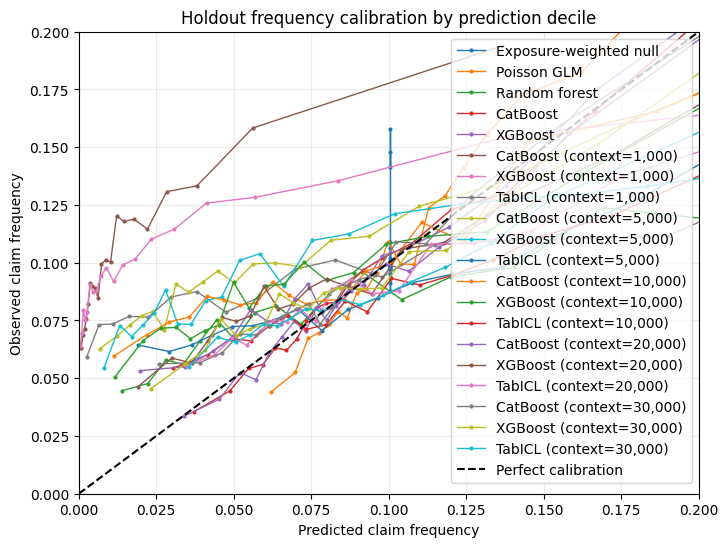

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
for model_name, prediction in predicted_claims.items():
    # if model_name == 'Exposure-weighted null':
    #     continue

    calibration = pd.DataFrame(
        {
            'PredictedClaims': prediction,
            'ObservedClaims': y_test_claims.to_numpy(),
            'Exposure': exposure_test.to_numpy(),
        }
    )
    calibration['PredictedFrequency'] = (
        calibration['PredictedClaims'] / calibration['Exposure']
    )
    calibration['Decile'] = pd.qcut(
        calibration['PredictedFrequency'].rank(method='first'),
        q=20,
        labels=False,
    )
    deciles = calibration.groupby('Decile', observed=True).agg(
        PredictedClaims=('PredictedClaims', 'sum'),
        ObservedClaims=('ObservedClaims', 'sum'),
        Exposure=('Exposure', 'sum'),
    )
    ax.plot(
        deciles['PredictedClaims'] / deciles['Exposure'],
        deciles['ObservedClaims'] / deciles['Exposure'],
        marker='o', 
        #thickeness of line & marker size
        linewidth=1,
        markersize=2,
        label=model_name,
    )

upper = max(ax.get_xlim()[1], ax.get_ylim()[1])
upper = 0.2
ax.plot([0, upper], [0, upper], linestyle='--', color='black', label='Perfect calibration')
ax.set_xlim(0, upper)
ax.set_ylim(0, upper)
ax.set_xlabel('Predicted claim frequency')
ax.set_ylabel('Observed claim frequency')
ax.set_title('Holdout frequency calibration by prediction decile')
ax.legend()
ax.grid(alpha=0.25)
plt.show()

## Interpretation and actuarial caveat

Use the table and calibration plot to compare models on this sampled holdout; do not interpret the scores as evidence that one model will win on the full portfolio. TabICL is pretrained and performs in-context learning at prediction time, rather than fitting neural-network weights on this sample.

All 678,013 rows from the local CSV are loaded. The full-data classical models fit the complete training partition with exposure weights; CatBoost and XGBoost context variants use exposure weights on the same nested rows as TabICL. Since TabICL's documented `fit(X, y)` API has no `sample_weight`, its contexts are nested prefixes of a row order stratified by `ClaimNb` bins (0, 1, 2+), but are not exposure-weighted. For production ratemaking, validate the exposure treatment on a time-based holdout and consider the TabICL context-sampling approach when interpreting comparisons.